In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser  # type: ignore
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from copy import deepcopy

import matplotlib.ticker as mticker
import matplotlib as mpl
import math
from toroidal_coordinates.Gardner_toroidal import * 


In [2]:
figure_path = 'Gardner_data_test/figures'

In [3]:
sys.path.append('.')
from toroidal_coordinates.toroidal_lifting import toroidal_lifting_distance
from toroidal_coordinates.Gardner_toroidal import Gardner_coord
from toroidal_coordinates.dreimac_toroidal import compute_toroidal_coords_dreimac
from toroidal_coordinates.compute_coord import visualize_tor_coords_x_traj, interp_arr
from utils import get_spikes, fit_para, toroidal_alignment, plot_barcode, get_ratemaps
from persistence_homology import computeDistanceMatrix
from angle_fns import circmean
from toroidal_coordinates.epsilon import compute_epsilon
from Gardner_data_test.Gardner_lifting_test import gaussian_smooth_toroidal, interpolate_2d_along_axis_0
from constants import *

from toroidal_coordinates.compute_coord import *
from toroidal_coordinates.toroidal_lifting import *

In [4]:
def Gardner_coord_temp(interp10: bool = False):
    folder = 'Toroidal_topology_grid_cell_data/'

    rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')
    sspikes,xx,yy,__,__ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                        bSmooth = True, bSpeed = True, folder = folder )
    if interp10:
        sspikes = interpolate_2d_along_axis_0(sspikes, sspikes.shape[0]*10) # makes sspikes 10 times longer

    # coords, times = compute_toroidal_coords_dreimac(d, standard_range=False, distance_matrix=True)
    coords, times, _, _ = Gardner_coord(sspikes)

    compute_epsilon(coords)
    plt.show()

    xx = interp_arr(xx, coords.shape[0])
    yy = interp_arr(yy, coords.shape[0])
    times = np.arange(xx.shape[0])
    visualize_tor_coords_x_traj(xx, yy, coords, times)

    # coordsbox, times_box, centcosall, centsinall = Gardner_coord(sspikes, xx, yy)
    print(coords.shape, times.shape, xx.shape, yy.shape)
    plt.show()
    # import pdb; pdb.set_trace()
    lifted_coords = toroidal_lifting_distance(coords)

    smooth_factor = 10
    if interp10:
        smooth_factor = 100
    
    lifted_coords[:, 0] = gaussian_smooth_toroidal(lifted_coords[:, 0], smooth_factor)
    lifted_coords[:, 1] = gaussian_smooth_toroidal(lifted_coords[:, 1], smooth_factor)

    original_coords = np.concatenate([xx[:, None], yy[:, None]], axis=1)

    return lifted_coords, original_coords

In [5]:
def Gardner_coord_temp_without_smoothing(interp10: bool = False):
    folder = 'Toroidal_topology_grid_cell_data/'

    rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')
    sspikes,xx,yy,__,__ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                        bSmooth = True, bSpeed = True, folder = folder )
    if interp10:
        sspikes = interpolate_2d_along_axis_0(sspikes, sspikes.shape[0]*10) # makes sspikes 10 times longer

    # coords, times = compute_toroidal_coords_dreimac(d, standard_range=False, distance_matrix=True)
    coords, times, _, _ = Gardner_coord(sspikes)

    compute_epsilon(coords)
    plt.show()

    xx = interp_arr(xx, coords.shape[0])
    yy = interp_arr(yy, coords.shape[0])
    times = np.arange(xx.shape[0])
    visualize_tor_coords_x_traj(xx, yy, coords, times)

    # coordsbox, times_box, centcosall, centsinall = Gardner_coord(sspikes, xx, yy)
    print(coords.shape, times.shape, xx.shape, yy.shape)
    plt.show()
    # import pdb; pdb.set_trace()
    lifted_coords = toroidal_lifting_distance(coords)

    # smooth_factor = 10
    # if interp10:
    #     smooth_factor = 100
    
    # lifted_coords[:, 0] = gaussian_smooth_toroidal(lifted_coords[:, 0], smooth_factor)
    # lifted_coords[:, 1] = gaussian_smooth_toroidal(lifted_coords[:, 1], smooth_factor)

    original_coords = np.concatenate([xx[:, None], yy[:, None]], axis=1)

    return lifted_coords, original_coords

In [6]:
folder = 'Toroidal_topology_grid_cell_data/'

rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')
sspikes,xx,yy,__,__ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                            bSmooth = True, bSpeed = True, folder = folder )

# coords, times = compute_toroidal_coords_dreimac(d, standard_range=False, distance_matrix=True)
coords, times, _, _ = Gardner_coord(sspikes)




/home/hyoon/GridCellDecoding/toroidal_coordinates/Gardner_toroidal.py:119: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


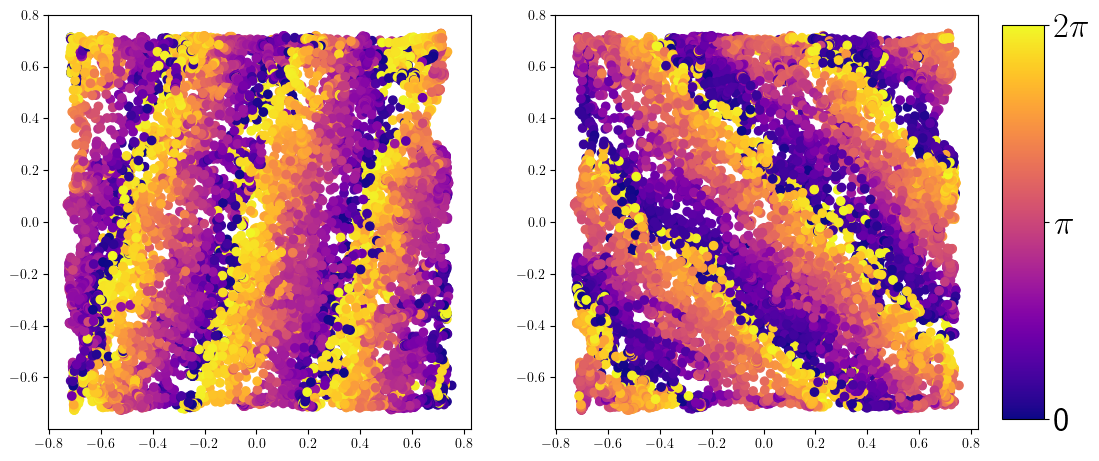

In [7]:
plot_toroidal_coordinates(xx, yy, coords, times, subsample_times = True)

plt.show()

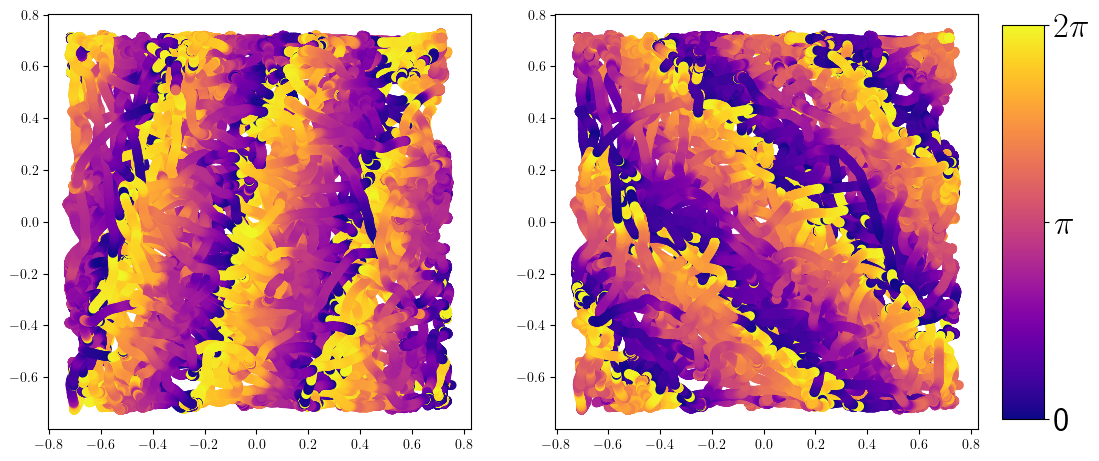

In [8]:
plot_toroidal_coordinates(xx, yy, coords, times)
#plt.savefig("Gardner_data_test/figures/toroidal_coords.png", bbox_inches='tight', transparent = True)
plt.show()

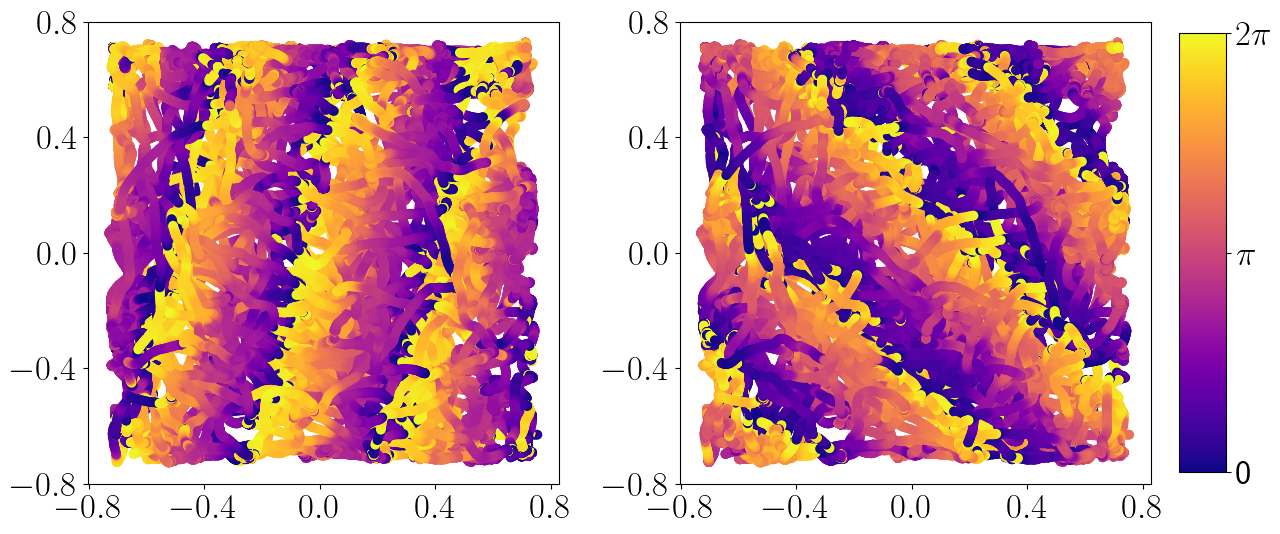

In [21]:
          
    plot_times = times

    xx = interp_arr(xx, coords.shape[0])
    yy = interp_arr(yy, coords.shape[0])
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    coords_color = [coords[times[plot_times], 0], coords[times[plot_times],1]]

    sc0 = ax[0].scatter(xx[times][plot_times], yy[times][plot_times], c=coords_color[0], cmap='plasma')
    ax[0].set_xticks([-0.8, -0.4, 0, 0.4, 0.8])
    ax[0].set_yticks([-0.8, -0.4, 0, 0.4, 0.8])

    ax[0].set_aspect('equal')
    ax[0].tick_params(axis='both', labelsize=25) 

    sc1 = ax[1].scatter(xx[times][plot_times], yy[times][plot_times], c=coords_color[1], cmap='plasma')
    ax[1].set_xticks([-0.8, -0.4, 0, 0.4, 0.8])
    ax[1].set_yticks([-0.8, -0.4, 0, 0.4, 0.8])

    ax[1].set_aspect('equal')
    ax[1].tick_params(axis='both', labelsize=25) 
    
    pos = ax[1].get_position()
    
    # Compute colorbar dimensions:
    # Width: 1/3 of the scatter plot width.
    width_ax = pos.width
    width_cbar = width_ax * (1/10)
    # Height: 80% of scatter plot height.
    height_ax = pos.height
    height_cbar = height_ax * 0.95
    # Horizontal pad between ax[1] and colorbar.
    pad = 0.02  
    x_cbar = pos.x1 + pad
    y_cbar = pos.y0 + (height_ax - height_cbar) / 2

    # Add a new axis for the colorbar at the computed position.
    cax = fig.add_axes([x_cbar, y_cbar, width_cbar, height_cbar]) # type: ignore
   
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm = mpl.colors.Normalize(vmin = 0, vmax = 2 * math.pi), cmap = "plasma"), 
                        cax=cax, ticks=np.arange(0, 2*math.pi+0.001, math.pi), format=mticker.FixedFormatter(['0', r'$\pi$', r'$2\pi$']))
    
    cbar.set_ticks(np.arange(0, 2*math.pi+0.001, math.pi))
    cbar.ax.tick_params(labelsize=25)


plt.savefig("Gardner_data_test/figures/toroidal_coords.pdf", bbox_inches='tight', transparent = True)

/home/hyoon/GridCellDecoding/toroidal_coordinates/Gardner_toroidal.py:119: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


3.9793359622685216
(126728, 2)
(126728, 2) (126728,) (126728,) (126728,)


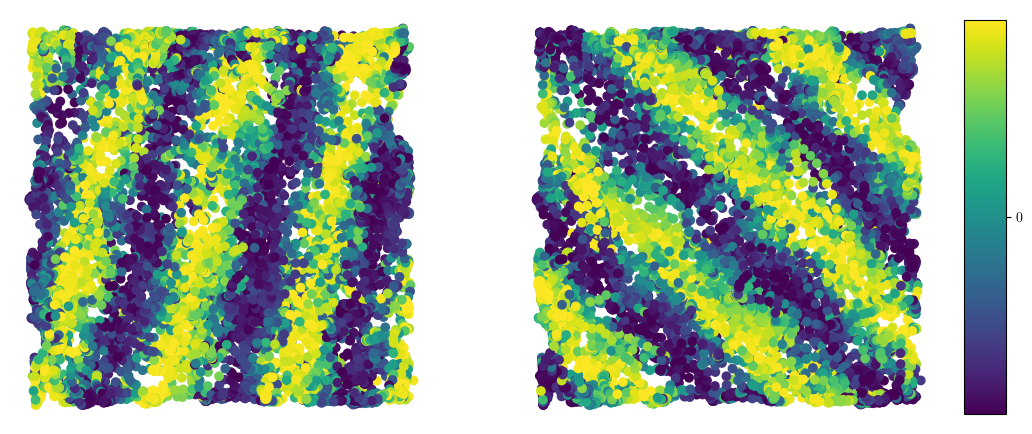

3.9793359622685216


In [11]:
# without interpolation 
lifted, original = Gardner_coord_temp_without_smoothing(interp10=False)

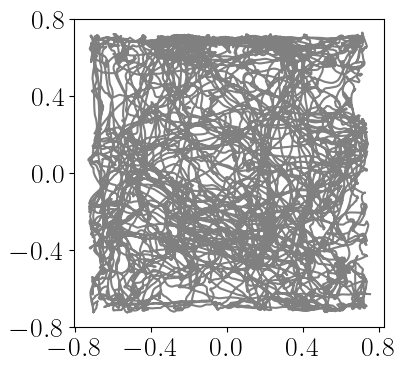

In [22]:
plt.figure(figsize = (4,4))
plt.plot(original[:, 0], original[:, 1], color = "grey")
plt.xticks([-0.8, -0.4, 0.0, 0.4, 0.8])
plt.yticks([-0.8, -0.4, 0.0, 0.4, 0.8])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig("Gardner_data_test/figures/original_trajectory.pdf", bbox_inches='tight', transparent = True)
plt.show()


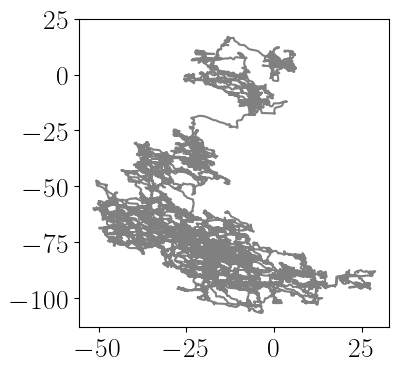

In [23]:
plt.figure(figsize = (4,4))
plt.plot(lifted[:, 0], lifted[:, 1], color = "grey")
plt.xticks([-50, -25, 0, 25])
plt.yticks([-100, -75, -50, -25, 0, 25])
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.savefig("Gardner_data_test/figures/lifted_trajectory.pdf", bbox_inches='tight', transparent = True)
plt.show()


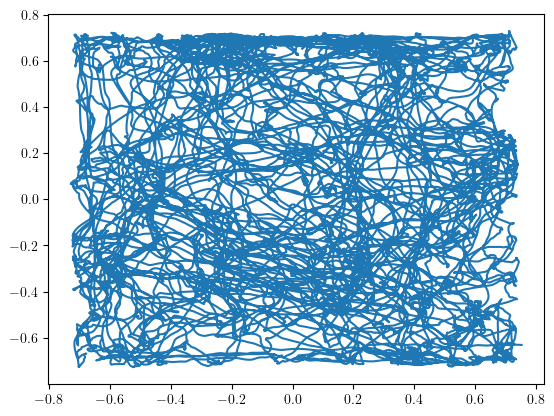

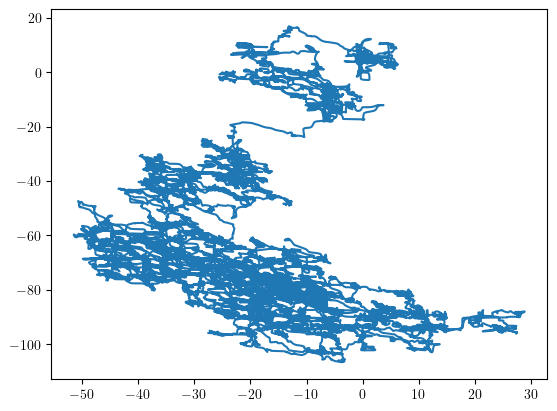

In [14]:
# without interpolation 

plt.figure()
plt.plot(original[:, 0], original[:, 1])
plt.figure()
plt.plot(lifted[:, 0], lifted[:, 1])
#plt.savefig(os.path.join(GARDNER_TEST_FIG_PATH, 'lifted_traj.png'), dpi=500)

### Plot persistence diagram (uninterpolated)

In [ ]:
from figures.plot_persistence_diagram import *

In [ ]:
folder = 'Toroidal_topology_grid_cell_data/'

rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')
sspikes,xx,yy,__,__ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                    bSmooth = True, bSpeed = True, folder = folder )

persistence = Gardner_persistence(sspikes, maxdim = 2)

/home/hyoon/GridCellDecoding/toroidal_coordinates/Gardner_toroidal.py:62: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


In [ ]:
PD0 = persistence['dgms'][0]
PD1 = persistence['dgms'][1]
PD2 = persistence['dgms'][2]

# np.savez('Gardner_data_test/figures/persistence_diagrams.npz', 
#           PD0=PD0, 
#           PD1=PD1,
#           PD2=PD2)

(-1.352988338470459, 15.35641764163971)

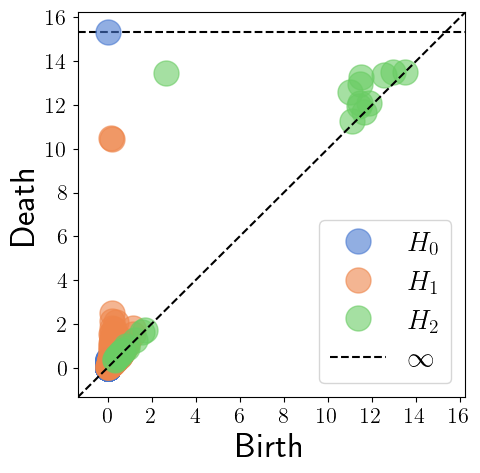

In [ ]:
plot_persistence_diagram([PD0, PD1, PD2],
                         #savefig ='Gardner_data_test/figures/persistence_diagrams.pdf'
                         ) 

PD1 looks like one point, but there are two points

## Comparing the lifted paths with the original paths by segments

### Uninterpolated

In [41]:
from affine_transform.get_transform_mat import get_transform_mat, apply_transform_mat
from affine_transform.score_mismatch import score_mismatch
np.random.seed(0)
len_seg = 2000
len_seg10 = len_seg*10
colors = plt.cm.viridis(np.linspace(0, 1, len_seg))
colors10 = plt.cm.viridis(np.linspace(0, 1, len_seg10))

In [42]:
num_seg = lifted.shape[0]//len_seg+1
print(num_seg)
uninterp_mismatch = []
for i in range(num_seg):
    original_seg = original[i*len_seg:(i+1)*len_seg]
    lifted_seg = lifted[i*len_seg:(i+1)*len_seg]
    transform_mat = get_transform_mat(lifted_seg, original_seg)
    recovered_lifted = apply_transform_mat(lifted_seg, transform_mat)
    uninterp_mismatch.append(score_mismatch(recovered_lifted, original_seg))
    if i < num_seg - 1:
        plt.figure(figsize=(6, 3))
        plt.subplot(1, 2, 1)
        plt.scatter(original_seg[:, 0], original_seg[:, 1], marker='.', color=colors)
        plt.subplot(1, 2, 2)
        plt.scatter(recovered_lifted[:, 0], recovered_lifted[:, 1], marker='.', color=colors)
        plt.savefig(os.path.join(GARDNER_TEST_FIG_PATH, 'lifted_segments_without_smoothing', f'seg_{i}.png'), dpi=500)
        plt.close()

64


### Plot segment 2 in detail

In [17]:
i = 2
original_seg = original[i*len_seg:(i+1)*len_seg]
lifted_seg = lifted[i*len_seg:(i+1)*len_seg]
coords_seg = coords[i*len_seg:(i+1)*len_seg]
transform_mat = get_transform_mat(lifted_seg, original_seg)
recovered_lifted = apply_transform_mat(lifted_seg, transform_mat)


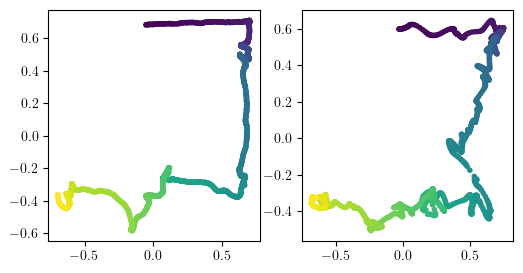

In [25]:
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.scatter(original_seg[:, 0], original_seg[:, 1], marker='.', color=colors)
plt.subplot(1, 2, 2)
plt.scatter(recovered_lifted[:, 0], recovered_lifted[:, 1], marker='.', color=colors)
#plt.savefig(os.path.join(GARDNER_TEST_FIG_PATH, 'lifted_segments', f'seg_{i}.png'), dpi=500)
plt.show()

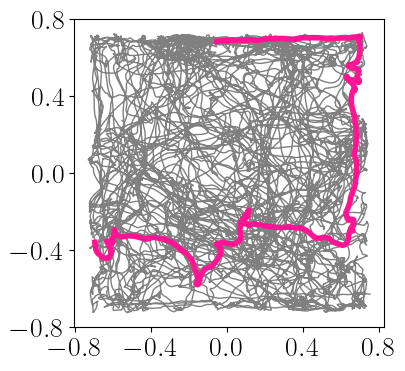

In [18]:
plt.figure(figsize= (4,4))
plt.plot(original[:,0],original[:,1], linewidth = 1, color = "grey")
plt.plot(original_seg[:,0],original_seg[:,1], color = "deeppink", linewidth = 4)
plt.xticks([-0.8, -0.4, 0.0, 0.4, 0.8])
plt.yticks([-0.8, -0.4, 0.0, 0.4, 0.8])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#plt.savefig("Gardner_data_test/figures/segment_2_highlighted.pdf", transparent = True, bbox_inches = "tight")
plt.show()

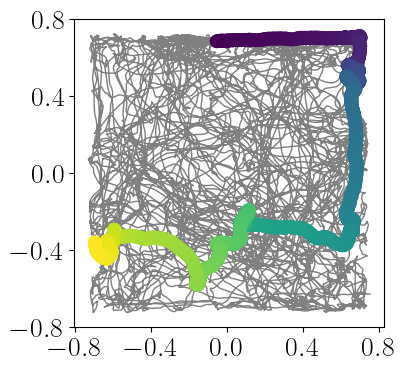

In [ ]:
plt.figure(figsize= (4,4))
plt.plot(original[:,0],original[:,1], linewidth = 1, color = "grey", zorder = 0)
plt.scatter(original_seg[:,0],original_seg[:,1], color = colors, linewidth = 4, zorder = 1)
plt.xticks([-0.8, -0.4, 0.0, 0.4, 0.8])
plt.yticks([-0.8, -0.4, 0.0, 0.4, 0.8])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#plt.savefig("Gardner_data_test/figures/segment_2_highlighted.pdf", transparent = True, bbox_inches = "tight")
plt.show()

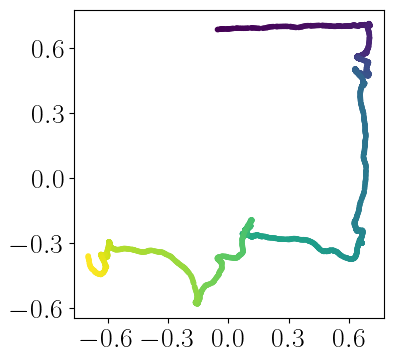

In [139]:
# original segment
plt.figure(figsize=(4, 4))
plt.scatter(original_seg[:, 0], original_seg[:, 1], marker='.', color=colors)
plt.xticks([-0.6, -0.3, 0, 0.3, 0.6], fontsize = 20)
plt.yticks([-0.6, -0.3, 0, 0.3, 0.6], fontsize = 20)
#plt.savefig("Gardner_data_test/figures/segment_2_original.pdf", bbox_inches='tight', transparent = True)
plt.show()

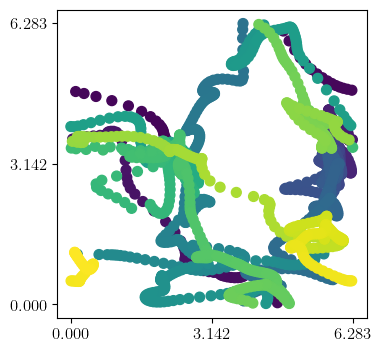

In [125]:
# plot the path on the torus
plt.figure(figsize = (4,4))
plt.scatter(coords_seg[:,0], coords_seg[:, 1], marker='.', s = 200, color =colors)
plt.xticks([0, math.pi, 2*math.pi], fontsize = 12)
plt.yticks([0, math.pi, 2*math.pi], fontsize = 12)
#plt.xticks([0, math.pi, 2*math.pi], [0, "π", "2π"], fontsize = 12)
#plt.yticks([0, math.pi, 2*math.pi], [0, "π", "2π"], fontsize = 12)
plt.savefig("Gardner_data_test/figures/segment_2_torus.pdf", bbox_inches='tight', transparent = True)
plt.show()

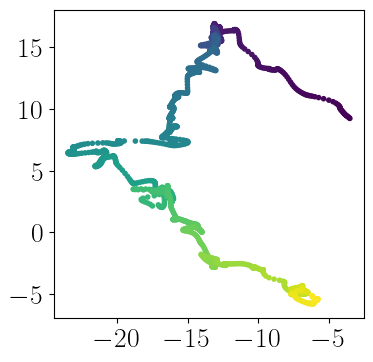

In [128]:
# lifted segment (without transformation)
plt.figure(figsize=(4,4))
plt.scatter(lifted_seg[:, 0], lifted_seg[:, 1], marker='.', color=colors)
plt.xticks([-20, -15, -10, -5], fontsize = 20)
plt.yticks([-5, 0, 5, 10, 15], fontsize = 20)
plt.savefig("Gardner_data_test/figures/segment_2_lifted.pdf", bbox_inches='tight', transparent = True)
plt.show()

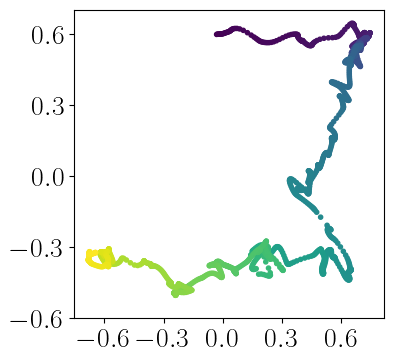

In [127]:
# lifted segment (with transformation)
plt.figure(figsize=(4, 4))
plt.scatter(recovered_lifted[:, 0], recovered_lifted[:, 1], marker='.', color=colors)
plt.xticks([-0.6, -0.3, 0, 0.3, 0.6], fontsize = 20)
plt.yticks([-0.6, -0.3, 0, 0.3, 0.6], fontsize = 20)
plt.savefig("Gardner_data_test/figures/segment_2_lifted_transformed.pdf", bbox_inches='tight', transparent = True)
plt.show()

### Plot segment 36 in detail

In [26]:
i = 36
original_seg = original[i*len_seg:(i+1)*len_seg]
lifted_seg = lifted[i*len_seg:(i+1)*len_seg]
coords_seg = coords[i*len_seg:(i+1)*len_seg]
transform_mat = get_transform_mat(lifted_seg, original_seg)
recovered_lifted = apply_transform_mat(lifted_seg, transform_mat)

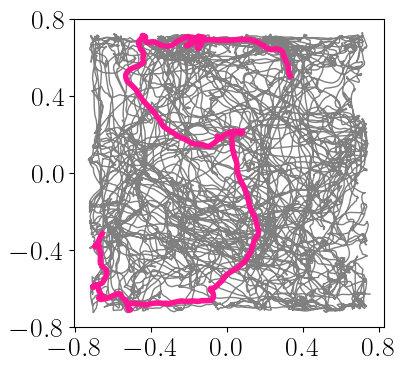

In [28]:
plt.figure(figsize= (4,4))
plt.plot(original[:,0],original[:,1], linewidth = 1, color = "grey")
plt.plot(original_seg[:,0],original_seg[:,1], color = "deeppink", linewidth = 4)
plt.xticks([-0.8, -0.4, 0.0, 0.4, 0.8])
plt.yticks([-0.8, -0.4, 0.0, 0.4, 0.8])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#plt.savefig("Gardner_data_test/figures/segment_36_highlighted.pdf", transparent = True, bbox_inches = "tight")
plt.show()

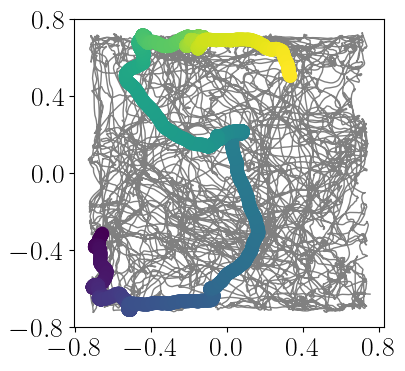

In [30]:
plt.figure(figsize= (4,4))
plt.plot(original[:,0],original[:,1], linewidth = 1, color = "grey", zorder = 0)
plt.scatter(original_seg[:,0],original_seg[:,1], color = colors, linewidth = 4, zorder = 1)
plt.xticks([-0.8, -0.4, 0.0, 0.4, 0.8])
plt.yticks([-0.8, -0.4, 0.0, 0.4, 0.8])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig("Gardner_data_test/figures/segment_36_highlighted.pdf", transparent = True, bbox_inches = "tight")
plt.show()

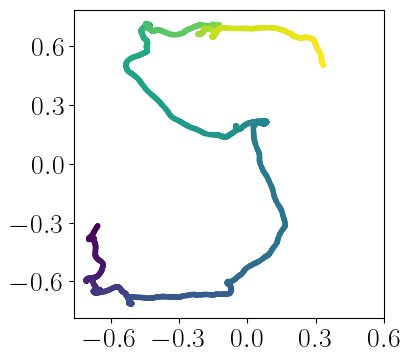

In [31]:
# original segment
plt.figure(figsize=(4, 4))
plt.scatter(original_seg[:, 0], original_seg[:, 1], marker='.', color=colors)
plt.xticks([-0.6, -0.3, 0, 0.3, 0.6], fontsize = 20)
plt.yticks([-0.6, -0.3, 0, 0.3, 0.6], fontsize = 20)
#plt.savefig("Gardner_data_test/figures/segment_36_original.pdf", bbox_inches='tight', transparent = True)
plt.show()

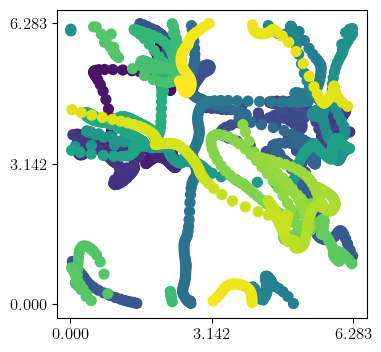

In [32]:
# plot the path on the torus
plt.figure(figsize = (4,4))
plt.scatter(coords_seg[:,0], coords_seg[:, 1], marker='.', s = 200, color =colors)
plt.xticks([0, math.pi, 2*math.pi], fontsize = 12)
plt.yticks([0, math.pi, 2*math.pi], fontsize = 12)
#plt.xticks([0, math.pi, 2*math.pi], [0, "π", "2π"], fontsize = 12)
#plt.yticks([0, math.pi, 2*math.pi], [0, "π", "2π"], fontsize = 12)
plt.savefig("Gardner_data_test/figures/segment_36_torus.pdf", bbox_inches='tight', transparent = True)
plt.show()

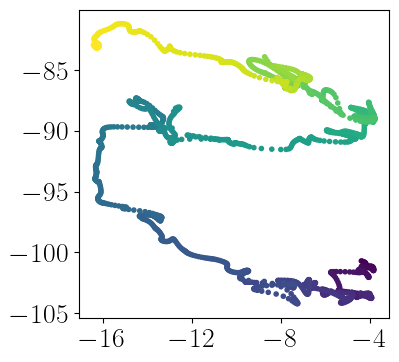

In [ ]:
# lifted segment (without transformation)
plt.figure(figsize=(4,4))
plt.scatter(lifted_seg[:, 0], lifted_seg[:, 1], marker='.', color=colors)
plt.xticks([-16, -12, -8, -4], fontsize = 20)
plt.yticks([-105, -100, -95, -90, -85], fontsize = 20)
#plt.savefig("Gardner_data_test/figures/segment_36_lifted.pdf", bbox_inches='tight', transparent = True)
plt.show()

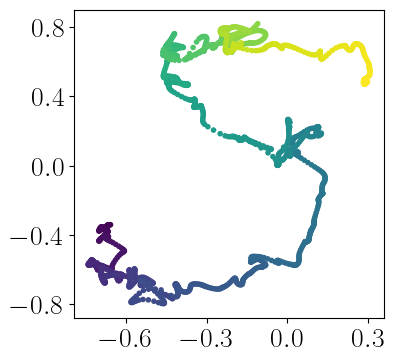

In [38]:
# lifted segment (with transformation)
plt.figure(figsize=(4, 4))
plt.scatter(recovered_lifted[:, 0], recovered_lifted[:, 1], marker='.', color=colors)
plt.xticks([-0.6, -0.3, 0, 0.3], fontsize = 20)
plt.yticks([-0.8, -0.4, 0, 0.4, 0.8], fontsize = 20)
plt.savefig("Gardner_data_test/figures/segment_36_lifted_transformed.pdf", bbox_inches='tight', transparent = True)
plt.show()

## Compare mismatch score distributions

0.10800934738550287


(array([10.,  8.,  4.,  6.,  5.,  2.,  1.,  3.,  7.,  6.,  3.,  2.,  2.,
         3.,  0.,  1.,  0.,  0.,  0.,  1.]),
 array([0.03577881, 0.04788931, 0.0599998 , 0.0721103 , 0.08422079,
        0.09633129, 0.10844178, 0.12055228, 0.13266277, 0.14477327,
        0.15688376, 0.16899426, 0.18110475, 0.19321525, 0.20532575,
        0.21743624, 0.22954674, 0.24165723, 0.25376773, 0.26587822,
        0.27798872]),
 <BarContainer object of 20 artists>)

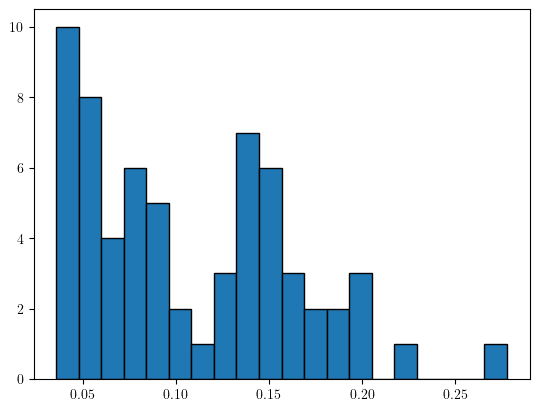

In [43]:
print(np.mean(uninterp_mismatch))
plt.hist(uninterp_mismatch, bins=20, edgecolor='black')

0.16546703504282692


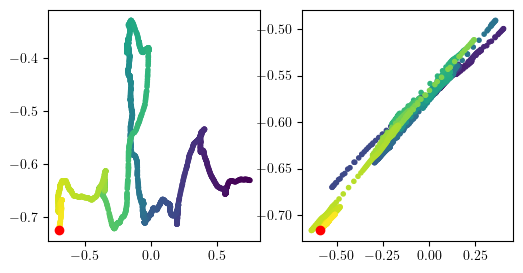

In [46]:

from scipy.spatial.distance import cdist # type: ignore
i=0
original_seg = original[i*len_seg:(i+1)*len_seg]
lifted_seg = lifted[i*len_seg:(i+1)*len_seg]
coords_seg = coords[i*len_seg:(i+1)*len_seg]
transform_mat = get_transform_mat(lifted_seg, original_seg)
recovered_lifted = apply_transform_mat(lifted_seg, transform_mat)
print(score_mismatch(recovered_lifted, original_seg))
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.scatter(original_seg[:, 0], original_seg[:, 1], marker='.', color=colors)
plt.scatter(original_seg[-1, 0], original_seg[-1, 1], marker='o', color='red')
plt.subplot(1, 2, 2)
plt.scatter(recovered_lifted[:, 0], recovered_lifted[:, 1], marker='.', color=colors)
plt.scatter(recovered_lifted[-1, 0], recovered_lifted[-1, 1], marker='o', color='red')

In [47]:
def euclidean_distance():
    return np.sqrt(np.sum((x-y)**2))

In [48]:
print(cdist(recovered_lifted, original_seg, metric='euclidean').diagonal())

[0.76196692 0.76361678 0.76279905 ... 0.1210026  0.11685763 0.11461998]


In [49]:
# pair-wise comparison to generate a null space mismatch
all_original_segs = np.array([original[i*len_seg:(i+1)*len_seg] for i in range(num_seg-1)])

In [ ]:
mismatch_matrix = np.zeros((num_seg-1, num_seg-1))
for i in range(num_seg-1):
    for j in range(i+1, num_seg-1):
        original_seg1 = all_original_segs[i]
        original_seg2 = all_original_segs[j]
        affine_mat = get_transform_mat(original_seg2, original_seg1)
        transformed_seg2 = apply_transform_mat(original_seg2, affine_mat)
        mismatch_matrix[i, j] = score_mismatch(original_seg1, transformed_seg2)
np.save(os.path.join(GARDNER_TEST_FIG_PATH, 'null_mismatch_matrix.npy'), mismatch_matrix)

In [50]:
mismatch_matrix = np.load(os.path.join(GARDNER_TEST_FIG_PATH, 'null_mismatch_matrix.npy'))

In [51]:
print(mismatch_matrix)

[[0.         0.15847713 0.1592093  ... 0.20186536 0.18785657 0.23541925]
 [0.         0.         0.13683648 ... 0.24953647 0.17118154 0.30428817]
 [0.         0.         0.         ... 0.244853   0.20063222 0.32767888]
 ...
 [0.         0.         0.         ... 0.         0.20168852 0.23115127]
 [0.         0.         0.         ... 0.         0.         0.20411219]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [52]:
null_mismatch = mismatch_matrix.flatten()
null_mismatch = null_mismatch[null_mismatch > 0]
null_mismatch.mean(), null_mismatch.std()

(0.2876296135728233, 0.08909597473131127)

In [53]:
from scipy.stats import ttest_ind
ttest_ind(uninterp_mismatch, null_mismatch)

TtestResult(statistic=-16.017174770154675, pvalue=1.923383692134414e-54, df=2015.0)

NameError: name 'original_seg1' is not defined

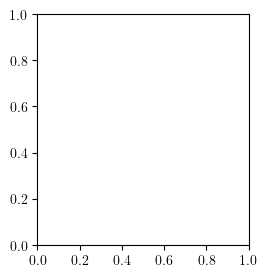

In [54]:
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.scatter(original_seg1[:, 0], original_seg1[:, 1], marker='.', color=colors)
plt.scatter(original_seg1[-1, 0], original_seg1[-1, 1], marker='o', color='red')
plt.subplot(1, 2, 2)
plt.scatter(transformed_seg2[:, 0], transformed_seg2[:, 1], marker='.', color=colors)
plt.scatter(transformed_seg2[-1, 0], transformed_seg2[-1, 1], marker='o', color='red')
print(score_mismatch(original_seg1, transformed_seg2))

(array([ 21.,  34.,  52.,  86., 127., 187., 189., 241., 229., 177., 176.,
        148., 103.,  77.,  34.,  33.,  19.,   9.,   8.,   3.]),
 array([0.0713336 , 0.09720799, 0.12308238, 0.14895677, 0.17483116,
        0.20070555, 0.22657994, 0.25245433, 0.27832872, 0.30420311,
        0.3300775 , 0.35595189, 0.38182628, 0.40770067, 0.43357506,
        0.45944945, 0.48532384, 0.51119823, 0.53707262, 0.56294701,
        0.5888214 ]),
 <BarContainer object of 20 artists>)

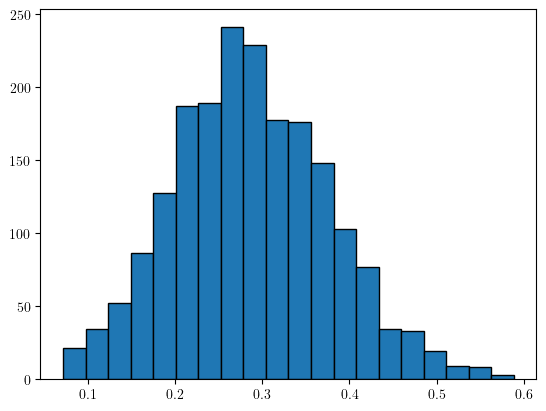

In [55]:
all_scores = mismatch_matrix.flatten()
all_scores = all_scores[all_scores != 0]
plt.hist(all_scores, bins=20, edgecolor='black')

In [57]:
import scipy.stats as stats
print(stats.ttest_ind(uninterp_mismatch, all_scores))


TtestResult(statistic=-16.017174770154675, pvalue=1.923383692134414e-54, df=2015.0)


In [59]:
len(uninterp_mismatch)

64

In [60]:
len(all_scores)

1953

/tmp/ipykernel_2441282/3668574344.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([uninterp_mismatch, all_scores],


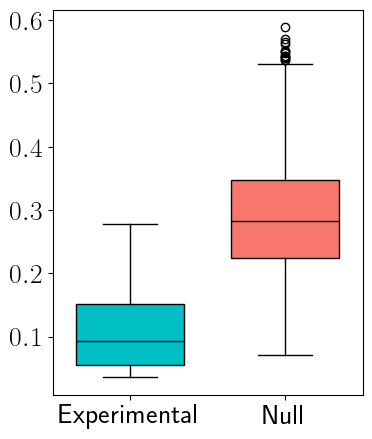

In [82]:
plt.figure(figsize=(4, 5))
bp = plt.boxplot([uninterp_mismatch, all_scores], 
                widths = 0.7,
                medianprops=dict(color='black'),
                patch_artist=True, labels=['Experimental', 'Null'])
colors = ['#00bfc4', '#f8776c']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)

plt.savefig("Gardner_data_test/figures/reconstruction_error_comparison.pdf", bbox_inches='tight', transparent = True)
plt.show()